In [9]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import numpy as np

TRAINED_SAE_DIR = Path("../results/trained_sae")  # adjust if notebook isn't in SAE/notebooks/
LAYER = 18

In [2]:
def load_run(run_dir: Path) -> pd.DataFrame:
    config = json.loads((run_dir / "config.json").read_text())
    metrics = json.loads((run_dir / "metrics.json").read_text())
    labels = json.loads((run_dir / "labels.json").read_text())
    firing_rate = metrics["firing_rate"]

    rows = []
    for rec in labels:
        lid = rec["latent_id"]
        rows.append({
            "run": run_dir.name,
            "n_latents": config["n_latents"],
            "latent_id": lid,
            "cluster_size": rec["cluster_size"],
            "firing_rate": firing_rate[lid],
            "status": rec["status"],
            "title": rec["title"],
            "description": rec["description"],
        })
    return pd.DataFrame(rows)


run_dirs = sorted(d for d in TRAINED_SAE_DIR.glob(f"L{LAYER:02d}_*") if (d / "labels.json").exists())
df = pd.concat([load_run(d) for d in run_dirs], ignore_index=True)
df.head()


,run,n_latents,latent_id,cluster_size,firing_rate,status,title,description
0,L18_n10_k3_uncentered_s0,10,0,0,0.000032,skipped_empty_cluster,NaN,NaN
1,L18_n10_k3_uncentered_s0,10,1,0,0.000058,skipped_empty_cluster,NaN,NaN
2,L18_n10_k3_uncentered_s0,10,2,62555,0.318175,ok,Relationship-advice list items,This latent fires on numbered-list markers and...
3,L18_n10_k3_uncentered_s0,10,3,0,0.000511,skipped_empty_cluster,NaN,NaN
4,L18_n10_k3_uncentered_s0,10,4,14680,0.017619,ok,Numbered list markers in advice responses,This latent fires on the numeric/bullet marker...


In [3]:
TOP_K = 10

for run_name, group in df.groupby("run", sort=False):
    print(f"\n=== {run_name} ===")
    top = group[group["status"] == "ok"].sort_values("cluster_size", ascending=False).head(TOP_K)
    for _, r in top.iterrows():
        print(f"  latent {r.latent_id:>3}  size={r.cluster_size:>7}  firing_rate={r.firing_rate:.4f}  {r.title}")




=== L18_n10_k3_uncentered_s0 ===
  latent   6  size= 200748  firing_rate=0.3520  Validating judgment statements (advice-column verdicts)
  latent   2  size=  62555  firing_rate=0.3182  Relationship-advice list items
  latent   7  size=  29239  firing_rate=0.0651  Numbered list item markers
  latent   4  size=  14680  firing_rate=0.0176  Numbered list markers in advice responses
  latent   8  size=      3  firing_rate=0.0000  Restating interpersonal context or plans

=== L18_n15_k3_uncentered_s0 ===
  latent   9  size= 776401  firing_rate=1.0000  Relationship-advice validation and boundary-setting language
  latent   4  size=  25875  firing_rate=0.0552  Numbered list item markers
  latent  11  size=  17641  firing_rate=0.0664  AITA-style verdict framing
  latent  12  size=  13377  firing_rate=0.0176  Empathetic-advice-response framing
  latent   1  size=      3  firing_rate=0.0000  Enthusiastic short affirmation
  latent   0  size=      3  firing_rate=0.0000  Single-word 'What' exclama

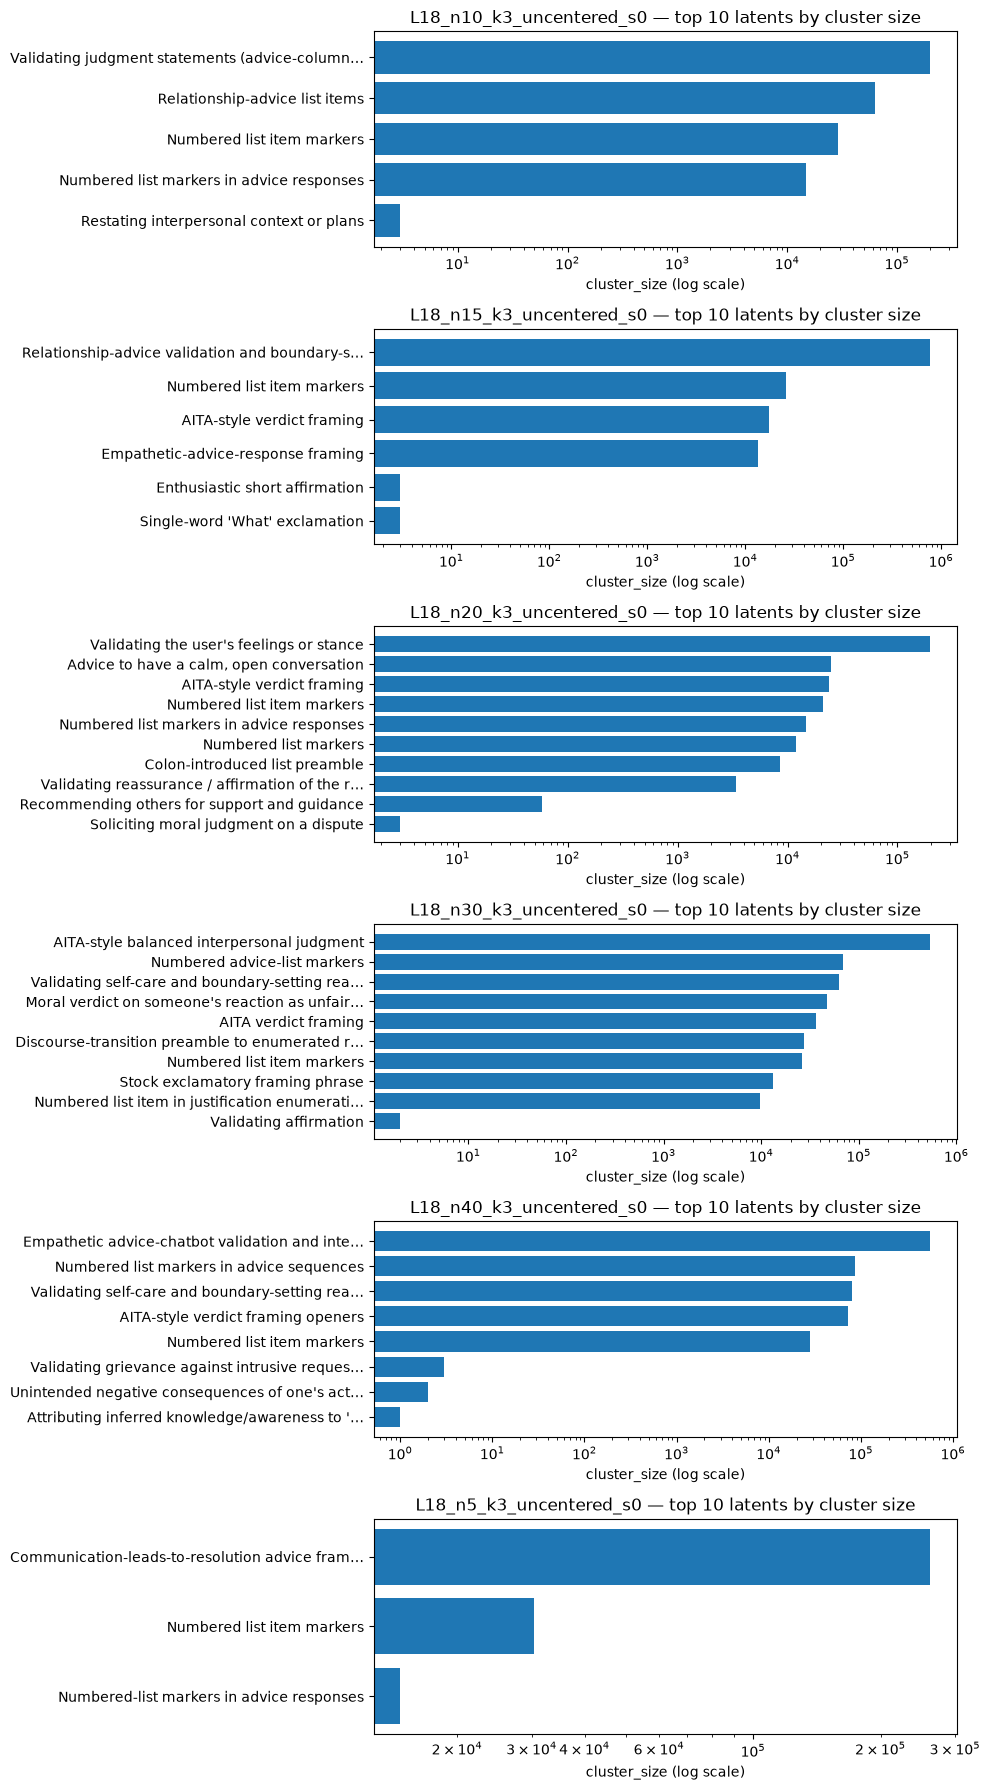

In [4]:
fig, axes = plt.subplots(len(run_dirs), 1, figsize=(10, 3 * len(run_dirs)), squeeze=False)

for ax, (run_name, group) in zip(axes[:, 0], df.groupby("run", sort=False)):
    top = group[group["status"] == "ok"].sort_values("cluster_size", ascending=False).head(TOP_K)
    top = top.iloc[::-1]  # smallest at top so barh reads largest-first top-to-bottom
    labels_wrapped = [f"{t[:45]}{'…' if len(t) > 45 else ''}" for t in top["title"]]
    ax.barh(labels_wrapped, top["cluster_size"])
    ax.set_xscale("log")
    ax.set_title(f"{run_name} — top {TOP_K} latents by cluster size")
    ax.set_xlabel("cluster_size (log scale)")

plt.tight_layout()
plt.show()


In [5]:
# Which titles recur across different dictionary sizes (n_latents)?
ok = df[df["status"] == "ok"].copy()
title_counts = ok["title"].value_counts()
print("Titles appearing in more than one run:")
print(title_counts[title_counts > 1])

Titles appearing in more than one run:
title
Numbered list item markers                               6
Numbered list markers in advice responses                2
AITA-style verdict framing                               2
Validating self-care and boundary-setting reassurance    2
Name: count, dtype: int64


In [6]:
# Full sortable summary, largest clusters first
pd.set_option("display.max_colwidth", 80)
ok.sort_values("cluster_size", ascending=False)[
    ["run", "latent_id", "cluster_size", "firing_rate", "title"]
].reset_index(drop=True).head(30)

,run,latent_id,cluster_size,firing_rate,title
0,L18_n15_k3_uncentered_s0,9,776401,1.000000,Relationship-advice validation and boundary-setting language
1,L18_n40_k3_uncentered_s0,23,566948,0.836998,Empathetic advice-chatbot validation and interpersonal coaching
2,L18_n30_k3_uncentered_s0,8,541101,0.650586,AITA-style balanced interpersonal judgment
3,L18_n5_k3_uncentered_s0,3,262225,0.351067,Communication-leads-to-resolution advice framing
4,L18_n10_k3_uncentered_s0,6,200748,0.352029,Validating judgment statements (advice-column verdicts)
5,L18_n20_k3_uncentered_s0,12,198932,0.356328,Validating the user's feelings or stance
6,L18_n40_k3_uncentered_s0,22,85976,0.244860,Numbered list markers in advice sequences
7,L18_n40_k3_uncentered_s0,27,80661,0.266426,Validating self-care and boundary-setting reassurance
8,L18_n40_k3_uncentered_s0,15,71766,0.228555,AITA-style verdict framing openers
9,L18_n30_k3_uncentered_s0,7,68563,0.186479,Numbered advice-list markers


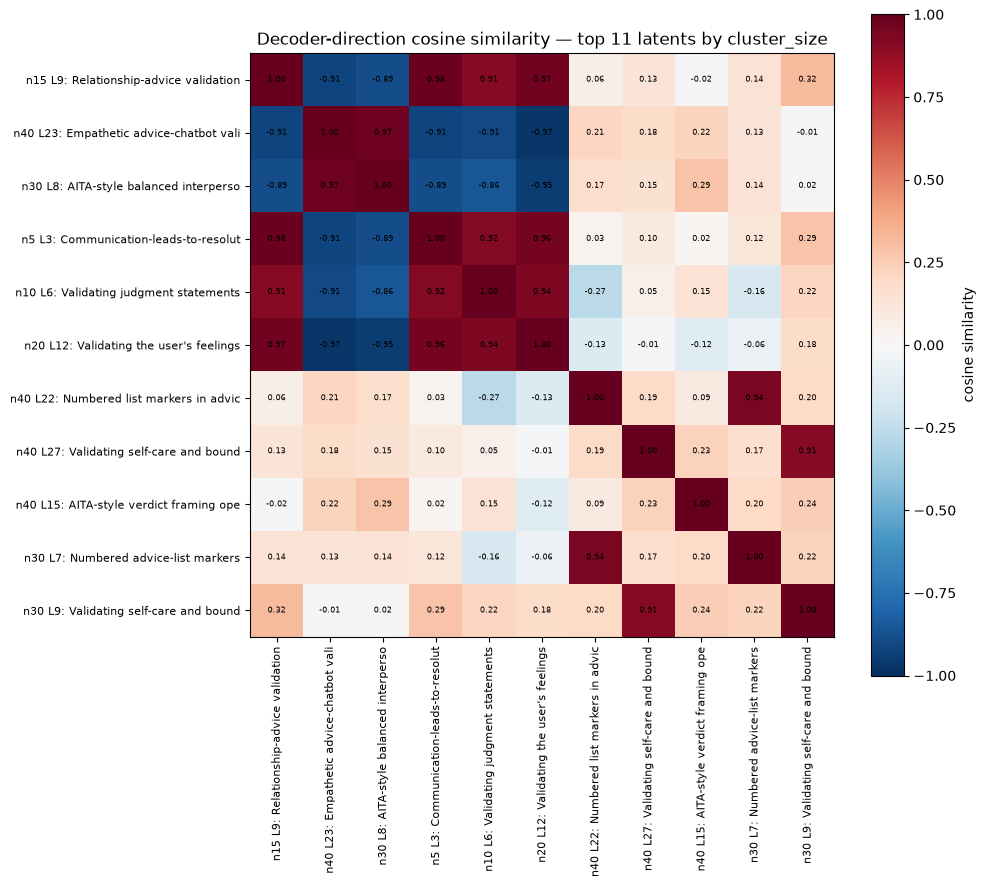

In [10]:


TOP_N = 11  # match the table above; bump this to compare more latents

top_rows = ok.sort_values("cluster_size", ascending=False).head(TOP_N).reset_index(drop=True)

def load_decoder_vector(run_name: str, latent_id: int) -> np.ndarray:
    state_dict = torch.load(TRAINED_SAE_DIR / run_name / "sae.pt", map_location="cpu")
    w_dec = state_dict["W_dec"]  # (d_in, n_latents), columns already unit-norm
    return w_dec[:, latent_id].numpy()

vectors = np.stack([load_decoder_vector(r.run, r.latent_id) for r in top_rows.itertuples()])
vectors = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)  # defensive re-normalize
cos_sim = vectors @ vectors.T

labels = [f"{r.run.split('_')[1]} L{r.latent_id}: {r.title[:30]}" for r in top_rows.itertuples()]

# %%
fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cos_sim, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{cos_sim[i, j]:.2f}", ha="center", va="center", fontsize=6)
fig.colorbar(im, ax=ax, label="cosine similarity")
ax.set_title(f"Decoder-direction cosine similarity — top {TOP_N} latents by cluster_size")
plt.tight_layout()
plt.show()
